<a href="https://colab.research.google.com/github/Vaibhavrsonawane2000/zepto-sales-analysis/blob/main/Zepto__Sales_Ana_ysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('/content/zepto_sales_dataset.csv')

In [3]:

df.head()
df.shape
df.columns

Index(['Product Name', 'Category', 'City', 'Original Price', 'Current Price',
       'Discount', 'Orders', 'Total Revenue', 'Influencer Active'],
      dtype='object')

In [4]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Product Name       300 non-null    object
 1   Category           300 non-null    object
 2   City               300 non-null    object
 3   Original Price     300 non-null    int64 
 4   Current Price      300 non-null    int64 
 5   Discount           300 non-null    int64 
 6   Orders             300 non-null    int64 
 7   Total Revenue      300 non-null    int64 
 8   Influencer Active  300 non-null    object
dtypes: int64(5), object(4)
memory usage: 21.2+ KB


np.int64(0)

In [5]:
df.describe()

,Original Price,Current Price,Discount,Orders,Total Revenue
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,111.866667,119.200000,4.916667,168.153333,19277.836667
std,49.936102,50.462543,4.179468,74.258541,12744.470724
min,20.000000,21.000000,0.000000,50.000000,1392.000000
25%,71.750000,78.000000,0.000000,103.750000,9025.250000
50%,115.000000,120.500000,5.000000,161.500000,16227.000000
75%,151.500000,161.000000,10.000000,233.750000,27396.000000
max,199.000000,213.000000,10.000000,299.000000,58212.000000


In [6]:
#Profit Per Order
df['Profit']=df['Current Price']-df['Original Price']

#Revenue Per Order
df['Revenue']=df['Total Revenue']/df['Orders']

**1. Which Category Generates Highest Revenue?**

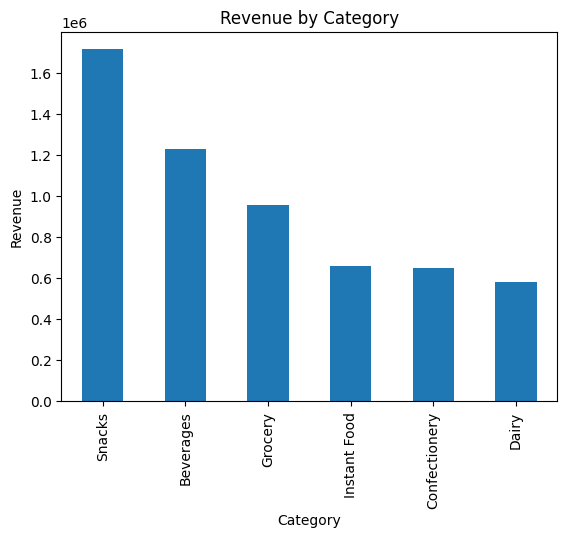

In [7]:
Category_revenue=df.groupby('Category')['Total Revenue'].sum().sort_values(ascending=False)
Category_revenue

Category_revenue.plot(kind='bar')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

**2. Which City Generates Highest Sales?**

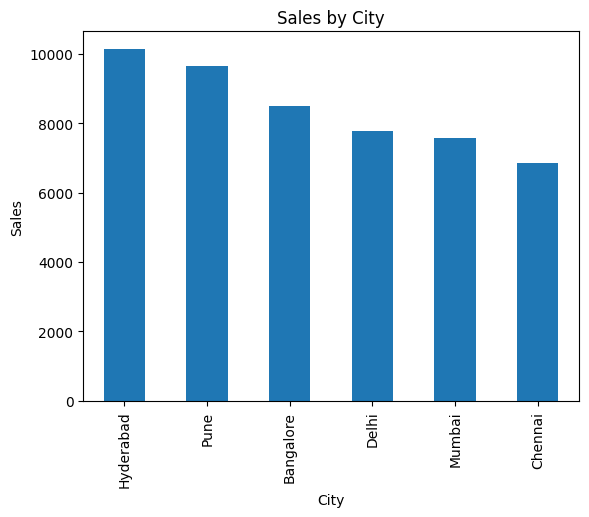

In [8]:
City_sales=df.groupby('City')['Orders'].sum().sort_values(ascending=False)
City_sales

City_sales.plot(kind='bar')
plt.title('Sales by City')
plt.xlabel('City')
plt.ylabel('Sales')
plt.show()

**3. Top 10 Products by Revenue**

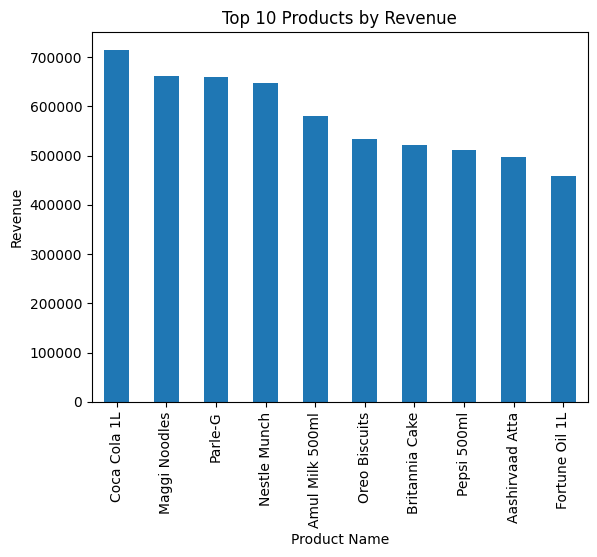

In [9]:
top_products=df.groupby('Product Name')['Total Revenue'].sum().sort_values(ascending=False).head(10)
top_products

top_products.plot(kind='bar')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Revenue')
plt.show()

**4. Does Influencer Marketing Increase Revenue?**

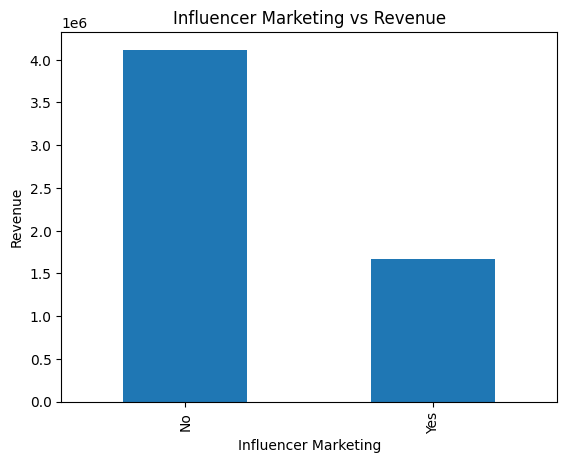

In [10]:
influencer_revenue=df.groupby('Influencer Active')['Total Revenue'].sum()
influencer_revenue

influencer_revenue.plot(kind='bar')
plt.title('Influencer Marketing vs Revenue')
plt.xlabel('Influencer Marketing')
plt.ylabel('Revenue')
plt.show()

**5. Discount vs Revenue Analysis**

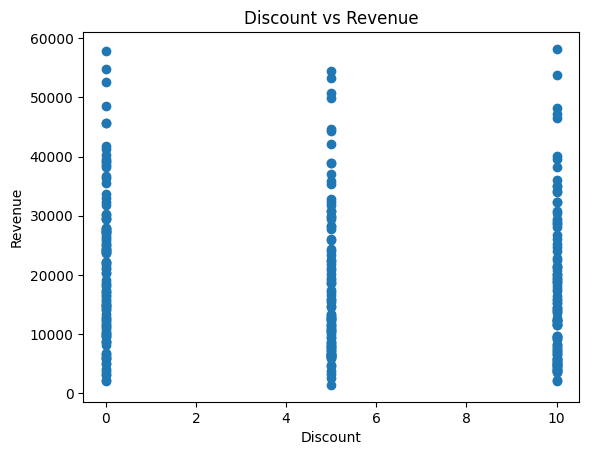

In [11]:
plt.scatter(df['Discount'],df['Total Revenue'])
plt.title('Discount vs Revenue')
plt.xlabel('Discount')
plt.ylabel('Revenue')
plt.show()

**6. Orders Distribution**

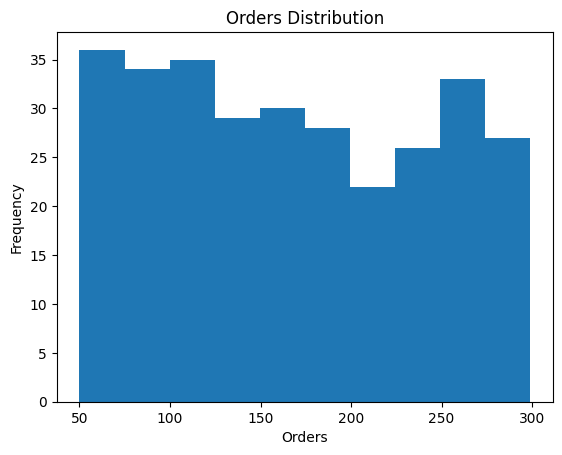

In [12]:
plt.hist(df['Orders'],bins=10)
plt.title('Orders Distribution')
plt.xlabel('Orders')
plt.ylabel('Frequency')
plt.show()

**Linear Regresssion**

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.metrics import mean_absolute_error

In [14]:
X=df[['Discount','Orders', 'Current Price', 'Original Price']]
y=df['Total Revenue']

In [15]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
Lr=LinearRegression()
Lr.fit(x_train,y_train)
y_pred=Lr.predict(x_test)

In [16]:
mae=mean_absolute_error(y_test,y_pred)
print('MAE', mae)
MSE=mean_squared_error(y_test,y_pred)
print('MSE',MSE)
R2=r2_score(y_test,y_pred)
print('R2',R2)


MAE 3347.2940577994
MSE 18780346.744636282
R2 0.8936658198694235


In [17]:
Comparison=pd.DataFrame({'Actual Revenue':y_test,'Predicted revenue':y_pred})
print(Comparison.head())

     Actual Revenue  Predicted revenue
203           35616       33497.101196
266            7560        4636.941208
152           10578       11734.456409
9             11859       21238.805472
233           20303       24034.291997


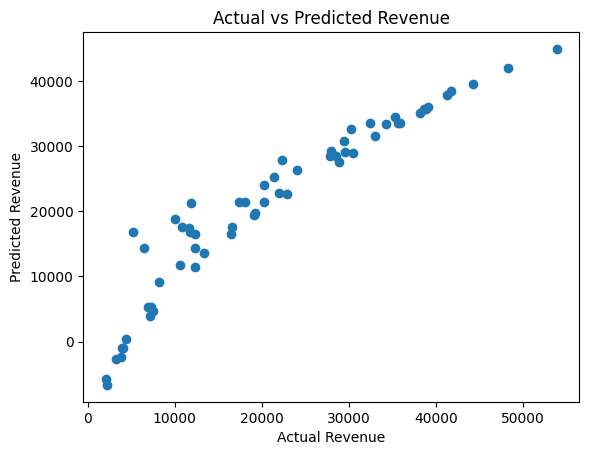

In [18]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.show()

In [19]:
Coefficients=pd.DataFrame({'Features':X.columns,'Coefficients':Lr.coef_})
print(Coefficients)

         Features  Coefficients
0        Discount   -218.292234
1          Orders    116.649877
2   Current Price    155.767466
3  Original Price     10.635723
